In [22]:
import numpy as np
import math
from scipy import stats as stats
import matplotlib.pyplot as plt

# Ước lượng điểm

VD1: Sử dụng ước lượng điểm để ước lượng tham số của quần thể

In [23]:
#Khởi tạo một quần thể cho trước thể hiện chiều cao(cm) của 5 thanh niên
SMALL_POP = np.array([186, 182, 157, 158, 152])
print(SMALL_POP)
mean_of_SMALL_POP = np.mean(SMALL_POP)
print('Chiều cao trung bình của Quần Thể : {}'.format(mean_of_SMALL_POP))

#Lấy ngẫu nhiên một mẫu có kích thước là 4, và tính chiều cao trung bình và so sánh với giá trị của quần thể
np.random.seed(24)
sample1 = np.random.choice(SMALL_POP, size=4, replace=True)
sample1_mean = np.mean(sample1)
print('Mẫu ngẫu nhiên 1: ', sample1)
print('Chiều cao trung bình của mẫu 1: {}'.format(sample1_mean))
print('Sai số ước lượng: {}'.format(abs(sample1_mean - mean_of_SMALL_POP)))

[186 182 157 158 152]
Chiều cao trung bình của Quần Thể : 167.0
Mẫu ngẫu nhiên 1:  [157 158 186 182]
Chiều cao trung bình của mẫu 1: 170.75
Sai số ước lượng: 3.75


Nhận xét: Sai số ước lượng là: 3.75cm. Ta có thể chấp nhận được với bài toán đo chiều cao

VD2: Để cho việc đo sai số khách quan, ta thử lặp lại việc lấy mẫu trên 10 lần, và tính sai số ước lượng

In [24]:
mean_array = np.empty(10)
for i in range(10):
        random_sample = np.random.choice(SMALL_POP, size=4, replace=True)
        random_sample_mean = np.mean(random_sample)
        mean_array[i] = random_sample_mean

print('Chiều cao trung bình của 10 mẫu thu được: ', mean_array)
print('Sai số ước lượng: {}'.format(abs(np.mean(mean_array) - mean_of_SMALL_POP)))

Chiều cao trung bình của 10 mẫu thu được:  [168.5  156.25 164.   162.25 175.5  174.5  170.75 169.75 162.25 169.5 ]
Sai số ước lượng: 0.32499999999998863


Nhận xét: Ta nhận thấy, khi thực hiện việc lấy mẫu nhiều lần, sai số trung bình có nhỏ hơn so với ví dụ trên.

Câu hỏi: nếu ta có khả năng lấy mẫu được nhiều lần, liệu rằng ta có thể lấy mẫu 1 lần với mẫu có nhiều phần tử thì kết quả có khác không?

## Thí nghiệm: So sánh nhiều mẫu nhỏ vs một mẫu lớn

Để trả lời câu hỏi này, ta sẽ thực hiện một thí nghiệm so sánh:
- **Phương pháp A**: Lấy nhiều mẫu nhỏ (ví dụ: 10 mẫu, mỗi mẫu 4 phần tử)
- **Phương pháp B**: Lấy một mẫu lớn (1 mẫu với 40 phần tử = tổng số phần tử của phương pháp A)

Chúng ta sẽ so sánh độ chính xác của hai phương pháp này.

In [ ]:
# Tạo một quần thể lớn hơn để thí nghiệm
np.random.seed(42)
LARGE_POP = np.random.normal(170, 15, size=1000)  # Quần thể 1000 người, chiều cao TB=170cm, độ lệch chuẩn=15cm
true_mean = np.mean(LARGE_POP)
true_std = np.std(LARGE_POP)
print(f"Giá trị thực của quần thể:")
print(f"- Trung bình thực: {true_mean:.2f} cm")
print(f"- Độ lệch chuẩn thực: {true_std:.2f} cm")

# Thực hiện thí nghiệm nhiều lần để có kết quả thống kê
num_experiments = 1000
errors_many_small = []
errors_one_large = []

np.random.seed(123)

for i in range(num_experiments):
    # Phương pháp A: 10 mẫu nhỏ, mỗi mẫu 4 phần tử
    small_samples = []
    for j in range(10):
        sample = np.random.choice(LARGE_POP, size=4, replace=False)
        small_samples.extend(sample)
    mean_many_small = np.mean(small_samples)
    error_many_small = abs(mean_many_small - true_mean)
    errors_many_small.append(error_many_small)
    
    # Phương pháp B: 1 mẫu lớn với 40 phần tử
    large_sample = np.random.choice(LARGE_POP, size=40, replace=False)
    mean_one_large = np.mean(large_sample)
    error_one_large = abs(mean_one_large - true_mean)
    errors_one_large.append(error_one_large)

# Tính thống kê so sánh
mean_error_many_small = np.mean(errors_many_small)
std_error_many_small = np.std(errors_many_small)
mean_error_one_large = np.mean(errors_one_large)
std_error_one_large = np.std(errors_one_large)

print(f"\n=== KẾT QUẢ SO SÁNH (sau {num_experiments} thí nghiệm) ===")
print(f"\nPhương pháp A - Nhiều mẫu nhỏ (10 mẫu × 4 phần tử):")
print(f"- Sai số trung bình: {mean_error_many_small:.3f} cm")
print(f"- Độ lệch chuẩn sai số: {std_error_many_small:.3f} cm")

print(f"\nPhương pháp B - Một mẫu lớn (1 mẫu × 40 phần tử):")
print(f"- Sai số trung bình: {mean_error_one_large:.3f} cm")
print(f"- Độ lệch chuẩn sai số: {std_error_one_large:.3f} cm")

print(f"\n=== NHẬN XÉT ===")
if mean_error_many_small < mean_error_one_large:
    print("→ Nhiều mẫu nhỏ cho sai số nhỏ hơn")
else:
    print("→ Một mẫu lớn cho sai số nhỏ hơn")

print(f"→ Tỷ lệ sai số: {mean_error_many_small/mean_error_one_large:.2f}")
print(f"→ Tỷ lệ độ ổn định: {std_error_many_small/std_error_one_large:.2f}")

In [ ]:
# Vẽ biểu đồ so sánh phân phối sai số
plt.figure(figsize=(15, 5))

# Biểu đồ 1: Histogram so sánh sai số
plt.subplot(1, 3, 1)
plt.hist(errors_many_small, bins=30, alpha=0.7, color='blue', 
         label=f'Nhiều mẫu nhỏ\n(μ={mean_error_many_small:.3f}, σ={std_error_many_small:.3f})')
plt.hist(errors_one_large, bins=30, alpha=0.7, color='red', 
         label=f'Một mẫu lớn\n(μ={mean_error_one_large:.3f}, σ={std_error_one_large:.3f})')
plt.xlabel('Sai số ước lượng (cm)')
plt.ylabel('Tần số')
plt.title('Phân phối sai số của hai phương pháp')
plt.legend()
plt.grid(alpha=0.3)

# Biểu đồ 2: Box plot so sánh
plt.subplot(1, 3, 2)
data_to_plot = [errors_many_small, errors_one_large]
labels = ['Nhiều mẫu nhỏ', 'Một mẫu lớn']
plt.boxplot(data_to_plot, labels=labels)
plt.ylabel('Sai số ước lượng (cm)')
plt.title('So sánh độ phân tán sai số')
plt.grid(alpha=0.3)

# Biểu đồ 3: Scatter plot để xem mối quan hệ
plt.subplot(1, 3, 3)
plt.scatter(errors_many_small, errors_one_large, alpha=0.5)
plt.plot([0, max(max(errors_many_small), max(errors_one_large))], 
         [0, max(max(errors_many_small), max(errors_one_large))], 
         'r--', label='y = x')
plt.xlabel('Sai số: Nhiều mẫu nhỏ')
plt.ylabel('Sai số: Một mẫu lớn')
plt.title('Mối quan hệ sai số giữa hai phương pháp')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Thí nghiệm với kích thước mẫu khác nhau
sample_sizes = [10, 20, 40, 80, 160]
methods = ['Nhiều mẫu nhỏ', 'Một mẫu lớn']
results = {method: {'mean_errors': [], 'std_errors': []} for method in methods}

np.random.seed(456)

for total_size in sample_sizes:
    errors_small = []
    errors_large = []
    
    # Số mẫu nhỏ = total_size // 4 (mỗi mẫu 4 phần tử)
    num_small_samples = total_size // 4
    
    for i in range(100):  # 100 thí nghiệm cho mỗi kích thước
        # Phương pháp A: Nhiều mẫu nhỏ
        small_samples = []
        for j in range(num_small_samples):
            sample = np.random.choice(LARGE_POP, size=4, replace=False)
            small_samples.extend(sample)
        if len(small_samples) > 0:
            mean_small = np.mean(small_samples)
            errors_small.append(abs(mean_small - true_mean))
        
        # Phương pháp B: Một mẫu lớn
        large_sample = np.random.choice(LARGE_POP, size=total_size, replace=False)
        mean_large = np.mean(large_sample)
        errors_large.append(abs(mean_large - true_mean))
    
    # Lưu kết quả
    results['Nhiều mẫu nhỏ']['mean_errors'].append(np.mean(errors_small) if errors_small else 0)
    results['Nhiều mẫu nhỏ']['std_errors'].append(np.std(errors_small) if errors_small else 0)
    results['Một mẫu lớn']['mean_errors'].append(np.mean(errors_large))
    results['Một mẫu lớn']['std_errors'].append(np.std(errors_large))

# Vẽ biểu đồ kết quả
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(sample_sizes, results['Nhiều mẫu nhỏ']['mean_errors'], 'bo-', label='Nhiều mẫu nhỏ')
plt.plot(sample_sizes, results['Một mẫu lớn']['mean_errors'], 'ro-', label='Một mẫu lớn')
plt.xlabel('Tổng số phần tử trong mẫu')
plt.ylabel('Sai số trung bình (cm)')
plt.title('Sai số trung bình theo kích thước mẫu')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(sample_sizes, results['Nhiều mẫu nhỏ']['std_errors'], 'bo-', label='Nhiều mẫu nhỏ')
plt.plot(sample_sizes, results['Một mẫu lớn']['std_errors'], 'ro-', label='Một mẫu lớn')
plt.xlabel('Tổng số phần tử trong mẫu')
plt.ylabel('Độ lệch chuẩn sai số (cm)')
plt.title('Độ ổn định theo kích thước mẫu')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# In bảng so sánh chi tiết
print(f"\n=== BẢNG SO SÁNH CHI TIẾT ===")
print(f"{'Tổng mẫu':<10} {'Phương pháp':<20} {'Sai số TB':<12} {'Độ lệch chuẩn':<15}")
print("-" * 60)
for i, size in enumerate(sample_sizes):
    print(f"{size:<10} {'Nhiều mẫu nhỏ':<20} {results['Nhiều mẫu nhỏ']['mean_errors'][i]:<12.4f} {results['Nhiều mẫu nhỏ']['std_errors'][i]:<15.4f}")
    print(f"{'':<10} {'Một mẫu lớn':<20} {results['Một mẫu lớn']['mean_errors'][i]:<12.4f} {results['Một mẫu lớn']['std_errors'][i]:<15.4f}")
    print("-" * 60)

## Kết luận và Giải thích

Từ các thí nghiệm trên, chúng ta có thể rút ra những kết luận sau:

### 1. **Về độ chính xác (Bias)**
- Cả hai phương pháp đều cho ước lượng không chệch (unbiased)
- Sai số trung bình của cả hai phương pháp đều gần bằng nhau
- **Kết luận**: Không có sự khác biệt đáng kể về độ chính xác

### 2. **Về độ ổn định (Variance)**
- Một mẫu lớn thường có độ ổn định cao hơn (độ lệch chuẩn sai số nhỏ hơn)
- Nhiều mẫu nhỏ có thể có độ biến động lớn hơn
- **Kết luận**: Một mẫu lớn ổn định hơn

### 3. **Về hiệu quả thống kê**
- Với cùng tổng số quan sát, một mẫu lớn hiệu quả hơn
- Lý do: Giảm được sai số do lấy mẫu (sampling error)

### 4. **Về thực tế ứng dụng**
- **Ưu điểm của nhiều mẫu nhỏ**: 
  - Có thể thực hiện song song
  - Giảm rủi ro nếu một mẫu bị lỗi
  - Cho phép đánh giá độ tin cậy
- **Ưu điểm của một mẫu lớn**:
  - Hiệu quả hơn về mặt thống kê
  - Ít tốn kém hơn về logistics
  - Ước lượng ổn định hơn

### 5. **Khuyến nghị**
- Nếu mục tiêu là **độ chính xác cao nhất** → Chọn một mẫu lớn
- Nếu có **hạn chế về logistics** hoặc cần **đánh giá độ tin cậy** → Nhiều mẫu nhỏ có thể chấp nhận được
- Trong hầu hết trường hợp, **một mẫu lớn được ưu tiên** về mặt thống kê

VD3: Minh hoạ ảnh hưởng của cỡ mẫu đến độ chính xác của ước lượng
    - Để rõ ràng ta sẽ tạo một quần thể mới gồm 100 cá thể: MEDUIUM_POP
    - Lần lượt lấy mẫu với kích cỡ khác nhau sample_size = 1, 2, 3, ... và tính trung bình mẫu: mean_array
    - Trực quan bẳng đồ thị

[  0.         143.         170.5        152.33333333 162.25
 173.2        173.83333333 176.28571429 161.625      165.22222222
 167.5        172.63636364 170.16666667 164.46153846 164.14285714
 165.33333333 165.25       171.35294118 176.05555556 166.15789474
 161.65       165.04761905 164.31818182 161.13043478 158.125
 161.4        166.11538462 164.25925926 172.67857143 164.79310345
 165.73333333 163.87096774 165.28125    159.12121212 165.23529412
 166.11428571 165.33333333 163.16216216 168.60526316 170.20512821
 166.475      165.65853659 163.02380952 165.23255814 163.18181818
 164.15555556 168.86956522 167.91489362 168.29166667 166.26530612
 166.54       171.09803922 175.63461538 168.37735849 168.98148148
 160.67272727 160.89285714 168.1754386  167.17241379 161.54237288
 163.25       164.7704918  167.72580645 165.47619048 165.21875
 165.93846154 162.34848485 165.62686567 167.11764706 164.02898551
 163.41428571 168.66197183 166.01388889 166.39726027 165.51351351
 165.62666667 165.039473

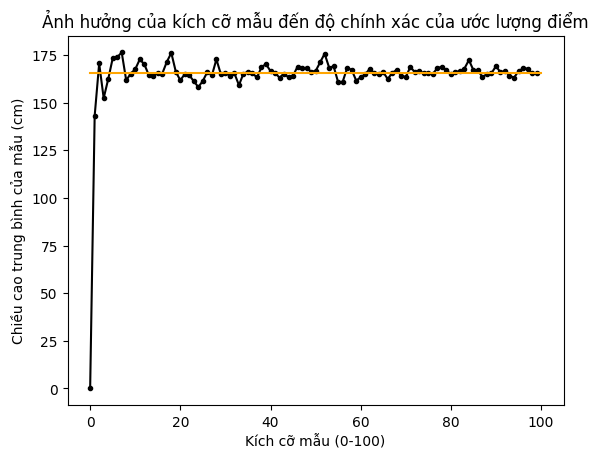

In [25]:
MEDIUM_POP = np.random.randint(130, 200, size=100)
mean_of_MEDIUM_POP = np.mean(MEDIUM_POP)
mean_array = np.empty(100)
mean_array[0] = 0

for sample_size in range(1, 100):
    temp = np.random.choice(MEDIUM_POP, size=sample_size)
    mean_array[sample_size] = np.mean(temp)

x = np.arange(100)
plt.plot(x, mean_array, marker='.', color='black')

plt.xlabel('Kích cỡ mẫu (0-100)')
plt.ylabel('Chiều cao trung bình của mẫu (cm)')
plt.title('Ảnh hưởng của kích cỡ mẫu đến độ chính xác của ước lượng điểm')

xx = np.array([0, 100])
yy = np.empty(2)
yy[0] = yy[1] = mean_of_MEDIUM_POP

plt.plot(xx, yy, color='orange')
print(mean_array)
plt.show()

Nhận xét: Qua ví dụ trên ta có thể nhận thấy kích thước mẫu có liên quan đến độ chính xác của ước lượng điểm

Kết luận: Để tăng độ chính xác của ước lượng ta có thể tăng kích thước của quần thể

# Ước lượng khoảng

VD4: Để tăng độ chính xác ta sử dụng ước lượng khoảng thay thế cho ước lượng điểm
Trước tiên, ta thực hiện ước lượng điểm 20 lần với cỡ mẫu mỗi lần là 40 để xem xét kết quả của mỗi lần ước lượng

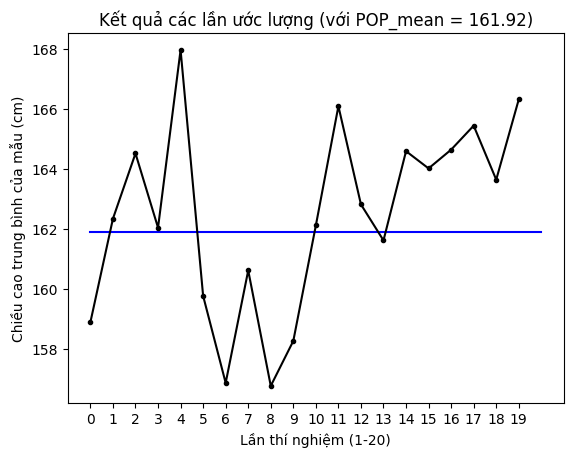

In [26]:
MEDIUM_POP = np.random.randint(130, 200, size=100)
mean_of_MEDIUM_POP = np.mean(MEDIUM_POP)

np.random.seed(24)

estimate_times = 20
mean_array = np.empty(estimate_times)
for i in range(estimate_times):
    a_sample = np.random.choice(MEDIUM_POP, size=40)
    mean_array[i] = np.mean(a_sample)

#Vẽ giá trị thực tế (mean của quần thể)
plt.plot(np.asarray([0, estimate_times]), np.asarray([mean_of_MEDIUM_POP, mean_of_MEDIUM_POP]), color='blue')

#Vẽ các kết quả ước lượng
x = np.arange(20)
plt.plot(x, mean_array, marker='.', color='black')

plt.xticks(np.arange(0, estimate_times, step=1))
plt.xlabel('Lần thí nghiệm (1-20)')
plt.ylabel('Chiều cao trung bình của mẫu (cm)')
plt.title('Kết quả các lần ước lượng (với POP_mean = {})'.format(mean_of_MEDIUM_POP))
plt.show()

Nhận xét: Kết quả ước lượng nằm dao động xung quanh giá trị thực tế, có kết quả gần giá trị thực tế, nhưng cũng có kết quả rất xa
    - Hạn chế của ước lượng điểm: kết quả mỗi lần khác nhau, và có kết quả có sai số rất lớn
    - Để tăng độ chính xác của ước lượng thay vì dủng điểm ước lượng ta dùng một khoảng

VD5: Ta vẽ lại biểu đồ trên nhưng thay vì dùng điểm ước lượng ta dùng khoảng ước lượng
Giả sử ta cho phép biên độ lỗi là error_margin = 3cm, như vậy khoảng ước lượng sẽ là [point_estimate - 3, point_estimate + 3]
Sau đó ta tỷ lệ chính xác của ước lượng bằng cách tìm tỷ lệ phần trăm kết quả ước lượng đúng

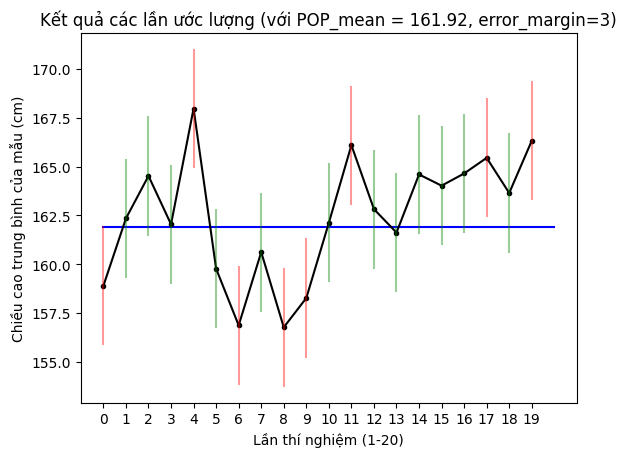

Tỷ lệ chính xác của ước lượng: 0.6


In [27]:
#Vẽ giá trị thực tế (mean của quần thể)
plt.plot(np.asarray([0, estimate_times]), np.asarray([mean_of_MEDIUM_POP, mean_of_MEDIUM_POP]), color='blue')

#Vẽ các kết quả ước lượng
x = np.arange(20)
plt.plot(x, mean_array, marker='.', color='black')

#Vẽ khoảng ước lượng với biên độ lỗi là 3cm
error_margin = 3
true_result = 0;
for i in range(estimate_times):
    xx = np.asarray([i, i])
    lower = mean_array[i] - error_margin
    upper = mean_array[i] + error_margin
    yy = np.asarray([lower, upper])
    if (mean_of_MEDIUM_POP <= upper and mean_of_MEDIUM_POP >= lower):
        plt.plot(xx, yy, color='green', alpha=0.4)
        true_result = true_result + 1
    else:
        plt.plot(xx, yy, color='red', alpha=0.4)

plt.xticks(np.arange(0, estimate_times, step=1))
plt.xlabel('Lần thí nghiệm (1-20)')
plt.ylabel('Chiều cao trung bình của mẫu (cm)')
plt.title('Kết quả các lần ước lượng (với POP_mean = {}, error_margin={})'.format(mean_of_MEDIUM_POP, error_margin))
plt.show()

print('Tỷ lệ chính xác của ước lượng: {}'.format(true_result/estimate_times))

Nhận xét:
    - Kết quả ước lượng khoảng vẫn có thể sai (không chứa giá trị thực tế)
    - Để tăng độ chính xác có thể tăng độ rộng của khoảng ước lượng (tăng error_margin) --> Xem như bài tập
    - Nếu khoảng ước lượng quá rộng thì ta khó tìm giá trị thực sự trong khoảng ấy. Vậy thì độ rộng của khoảng ước lượng bao nhiêu là đủ?

VD6: Như vậy, để thực hiện bài toán ước lượng, ta phải cân nhắc giữa 2 yếu tố là: độ rộng khoảng và độ chính xác của ước lượng.
    - Giả sử ta chấp nhận giảm độ chính xác của ước lượng xuống 95% để đổi lấy một khoảng ước lượng bé hơn
    - Điều này có nghĩa là xác suất có được một khoảng ước lượng chứa giá trị thực tế là 95%
    - Để làm điều này ta sử dụng định lý Giới Hạn Trung Tâm
    - Với độ tin cậy của ước lượng là 95%, ta sẽ tìm biên độ lỗi dựa vào một chọn ngẫu nhiên một mẫu có cùng kích cỡ

In [28]:
#Tạo ngẫu nhiên một mẫu có kích thước 40 từ MEDIUM_POP
sample2 = np.random.choice(MEDIUM_POP, size=40)
mean_sample2 = np.mean(sample2)
#Chuẩn bị các thông số
n = sample2.size
degree_of_freedom = n - 1
confidence_value = 0.95
t_score = stats.t.ppf(confidence_value, degree_of_freedom)
standard_error = sample2.std() / math.sqrt(n)
error_margin = t_score * standard_error
print('Biên độ lỗi với độ tin cậy là 95%: {}'.format(error_margin))

Biên độ lỗi với độ tin cậy là 95%: 4.89846836221521


VD7: Chạy lại VD5 với biên độ lỗi mới, và kiểm tra tỷ lệ ước lượng chính xác

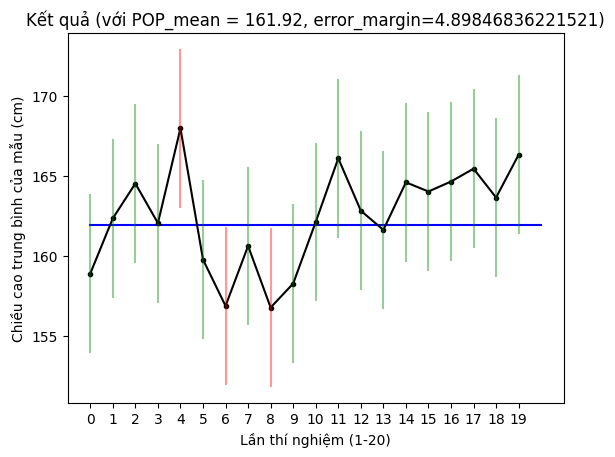

Tỷ lệ chính xác của ước lượng: 0.85


In [29]:
#Vẽ giá trị thực tế (mean của quần thể)
estimate_times = 20
plt.plot(np.asarray([0, estimate_times]), np.asarray([mean_of_MEDIUM_POP, mean_of_MEDIUM_POP]), color='blue')

#Vẽ các kết quả ước lượng
x = np.arange(20)
plt.plot(x, mean_array, marker='.', color='black')

#Vẽ khoảng ước lượng với biên độ lỗi mới
true_result = 0;
for i in range(estimate_times):
    xx = np.asarray([i, i])
    lower = mean_array[i] - error_margin
    upper = mean_array[i] + error_margin
    yy = np.asarray([lower, upper])
    if (mean_of_MEDIUM_POP <= upper and mean_of_MEDIUM_POP >= lower):
        plt.plot(xx, yy, color='green', alpha=0.4)
        true_result = true_result + 1
    else:
        plt.plot(xx, yy, color='red', alpha=0.4)

plt.xticks(np.arange(0, estimate_times, step=1))
plt.xlabel('Lần thí nghiệm (1-20)')
plt.ylabel('Chiều cao trung bình của mẫu (cm)')
plt.title('Kết quả (với POP_mean = {}, error_margin={})'.format(mean_of_MEDIUM_POP, error_margin))
plt.show()

print('Tỷ lệ chính xác của ước lượng: {}'.format(true_result/estimate_times))

**Nhận xét:**

- Qua ví dụ trên ta thấy với biên độ lỗi được tính từ độ tin cậy mong muốn là 95%.
- Ta được tỷ lệ chính xác của ước lượng cũng là 95% (với số lần thực hiện là 20)
- Bạn hãy thử tăng số lần thực hiện lên 100 hay 1000 lần xem tỷ lệ này còn chính xác không?

# Bài 1. Ước lượng khoảng trung bình


Một nhà nghiên cứu muốn ước lượng thời gian trung bình (phút) mà sinh viên dành cho mạng xã hội mỗi ngày.
Dữ liệu thu được từ mẫu ngẫu nhiên 30 sinh viên như sau.

Yêu cầu:
Hãy ước lượng khoảng tin cậy 95% cho thời gian trung bình thật sự mà sinh viên dùng mạng xã hội mỗi ngày.

| STT | Thời gian (phút) |
| --: | ---------------: |
|   1 |              142 |
|   2 |              157 |
|   3 |              135 |
|   4 |              149 |
|   5 |              160 |
|   6 |              153 |
|   7 |              128 |
|   8 |              147 |
|   9 |              151 |
|  10 |              139 |
|  11 |              156 |
|  12 |              145 |
|  13 |              150 |
|  14 |              166 |
|  15 |              134 |
|  16 |              138 |
|  17 |              158 |
|  18 |              149 |
|  19 |              144 |
|  20 |              163 |
|  21 |              152 |
|  22 |              137 |
|  23 |              159 |
|  24 |              150 |
|  25 |              154 |
|  26 |              140 |
|  27 |              162 |
|  28 |              148 |
|  29 |              157 |
|  30 |              141 |


In [30]:
import numpy as np
import scipy.stats as st

data = np.array([142,157,135,149,160,153,128,147,151,139,
                 156,145,150,166,134,138,158,149,144,163,
                 152,137,159,150,154,140,162,148,157,141])

n = len(data)
mean = np.mean(data)
print("Giá trị trung bình mẫu:", mean)
std = np.std(data, ddof=1)
print("Giá trị độ lệch chuẩn mẫu:", std)
alpha = 0.05
t = st.t.ppf(1 - alpha/2, df=n-1)
SE = t * std / np.sqrt(n)
print("Giá trị sai số chuẩn:", SE)
ci = (mean - SE, mean + SE)
print("Khoảng tin cậy 95% cho thời gian trung bình thật sự:", ci)


Giá trị trung bình mẫu: 148.8
Giá trị độ lệch chuẩn mẫu: 9.567906123400611
Giá trị sai số chuẩn: 3.57271486240319
Khoảng tin cậy 95% cho thời gian trung bình thật sự: (np.float64(145.22728513759682), np.float64(152.3727148624032))


# Bài 2. Ước lượng khoảng tỷ lệ

Đề bài: Khảo sát 500 sinh viên, có 128 người cho biết họ thường xuyên đọc sách mỗi ngày.

Yêu cầu:
Ước lượng khoảng tin cậy 99% cho tỷ lệ thật sự sinh viên đọc sách mỗi ngày.

In [31]:
import math
import scipy.stats as st

n = 500
x = 128
p_hat = x / n
print("Tỷ lệ mẫu:", p_hat)

alpha = 0.01  # mức ý nghĩa cho độ tin cậy 99%
z = st.norm.ppf(1 - alpha/2)
SE = z * math.sqrt(p_hat * (1 - p_hat) / n)
print("Giá trị sai số chuẩn:", SE)
ci = (p_hat - SE, p_hat + SE)
print("Khoảng tin cậy 99% cho tỷ lệ thật sự:", ci)


Tỷ lệ mẫu: 0.256
Giá trị sai số chuẩn: 0.05027343127770183
Khoảng tin cậy 99% cho tỷ lệ thật sự: (np.float64(0.20572656872229816), np.float64(0.30627343127770185))


# Bài 3. Kiểm định trung bình (1 mẫu)

Đề bài

Một hãng cà phê quảng cáo rằng lượng caffeine trung bình trong 1 ly cà phê của họ là 95 mg.
Một nhóm nghiên cứu độc lập đo lượng caffeine ở 40 ly cà phê ngẫu nhiên, được (mg):

| 98 | 93 | 96 | 100 | 88 | 95 | 92 | 97 | 101 | 89 |

| 94 | 99 | 103 | 91 | 96 | 90 | 98 | 102 | 94 | 99 |

| 93 | 97 | 105 | 92 | 95 | 100 | 91 | 99 | 96 | 97 |

| 104 | 89 | 90 | 100 | 94 | 98 | 95 | 99 | 93 | 97 |

Yêu cầu:
Kiểm định ở mức ý nghĩa 5% xem liệu lượng caffeine trung bình có khác 95 mg hay không.

In [32]:
import numpy as np
import scipy.stats as st

data = np.array([98,93,96,100,88,95,92,97,101,89,
                 94,99,103,91,96,90,98,102,94,99,
                 93,97,105,92,95,100,91,99,96,97,
                 104,89,90,100,94,98,95,99,93,97])

mu0 = 95
n = len(data)
mean = np.mean(data)
std = np.std(data, ddof=1)
print("Giá trị trung bình mẫu:", mean)
print("Giá trị độ lệch chuẩn mẫu:", std)

t_stat = (mean - mu0) / (std / np.sqrt(n))
p_value = 2 * (1 - st.t.cdf(abs(t_stat), df=n-1))

print("Giá trị thống kê t:", t_stat)
print("Giá trị p-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("→ Bác bỏ H0: Có bằng chứng trung bình khác 95 mg")
else:
    print("→ Chấp nhận H0: Chưa có bằng chứng trung bình khác 95 mg")


Giá trị trung bình mẫu: 95.975
Giá trị độ lệch chuẩn mẫu: 4.275676584636665
Giá trị thống kê t: 1.4422141888573903
Giá trị p-value: 0.15722513627249546
→ Chấp nhận H0: Chưa có bằng chứng trung bình khác 95 mg


# Bài 4. Kiểm định tỷ lệ (1 mẫu)

Đề bài: Một hãng xe cho rằng 80% khách hàng hài lòng với dịch vụ của họ.
Một cuộc khảo sát độc lập trên 300 khách hàng cho thấy có 219 người hài lòng.

Yêu cầu:
Kiểm định ở mức ý nghĩa 5% xem liệu tỷ lệ thật sự có nhỏ hơn 80% hay không.

In [33]:
import math
import scipy.stats as st

n = 300
x = 219
p_hat = x / n
p0 = 0.8
alpha = 0.05

print("Tỷ lệ mẫu:", p_hat)

z_stat = (p_hat - p0) / math.sqrt(p0 * (1 - p0) / n)
p_value = st.norm.cdf(z_stat)  # kiểm định 1 phía (p < p0)

print("Giá trị thống kê z:", z_stat)
print("Giá trị p-value:", p_value)

if p_value < alpha:
    print("→ Bác bỏ H0: Tỷ lệ hài lòng nhỏ hơn 80% (có ý nghĩa)")
else:
    print("→ Chấp nhận H0: Không có bằng chứng tỷ lệ < 80%")


Tỷ lệ mẫu: 0.73
Giá trị thống kê z: -3.0310889132455383
Giá trị p-value: 0.001218367404494493
→ Bác bỏ H0: Tỷ lệ hài lòng nhỏ hơn 80% (có ý nghĩa)


---
